In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

from pinnAdvancedv5PDE import PINN

In [2]:
def plotting(model, device='cpu'):
    """
    Creates a 2D contour/heatmap plot of the PINN solution.

    Args:
        model: The trained PINN model.
        device (str): The device ('cpu' or 'cuda') the model is on.
    """
    # 1. Create a regular grid of points for t and x
    t = torch.linspace(0, 1, 200)  # 200 points in time
    x = torch.linspace(-1, 1, 200) # 200 points in space
    
    # Create a meshgrid
    T, X = torch.meshgrid(t, x, indexing='ij')

    # 2. Prepare the grid for the model
    # Flatten the grid to create a batch of (t, x) points
    tx_grid = torch.stack((T.flatten(), X.flatten()), dim=1).to(device)

    # 3. Get predictions from the model on the grid
    u_pred = model.predict(tx_grid)
    
    # 4. Reshape the flat predictions back into a 2D grid
    U = u_pred.reshape(200, 200).cpu().numpy()

    # 5. Create the plot
    plt.figure(figsize=(10, 6))
    
    # Use pcolormesh for a heatmap, which is often clearer than contour
    plt.pcolormesh(T, X, U, shading='auto', cmap='viridis')
    
    # Add a color bar to show the mapping of colors to solution values
    plt.colorbar(label='Solution u(t, x)')
    
    plt.xlabel('Time (t)')
    plt.ylabel('Space (x)')
    plt.title("PINN Solution for Burgers' Equation")
    plt.show()


In [3]:
# Parameters of this problem:

file_to_save = "data_normalized.pkl"
normalize_jacobian = True
jac_test = np.logspace(0, 5, 40, endpoint=True)
#jac_test = np.logspace(2, 4, 10, endpoint=True)
n_epochs = 1_000_000
early_stopping_loss = 1e-15

num_coloc = 500
#x_co = np.exp(np.linspace(-15.0, 0.0, num_coloc))
x_co = np.logspace(-9, 0, num_coloc, endpoint=True)
x_co = torch.tensor(x_co, dtype=torch.float32).view(-1, 1).requires_grad_(True)


tx_pde = torch.rand(5000, 2)
tx_pde[:, 1] = 2 * tx_pde[:, 1] - 1  # Map x to [-1, 1]

_, sorted_indices = torch.sort(tx_pde[:, 0])
tx_pde = tx_pde[sorted_indices]

In [4]:
tx_pde

tensor([[3.1292e-04, 2.7399e-02],
        [3.3098e-04, 5.1010e-01],
        [1.4536e-03, 9.5817e-01],
        ...,
        [9.9958e-01, 1.3698e-01],
        [9.9965e-01, 3.3969e-01],
        [9.9970e-01, 3.1559e-01]])

In [5]:
def make_loss(nu=0.01 / np.pi, ic_weight=100.0, bc_weight=100.0, normalize_jac=False):
    """
    Factory function to create the PINN loss for Burgers' equation,
    including initial and boundary condition losses.
    
    Args:
        nu (float): The viscosity coefficient.
        ic_weight (float): Weight for the initial condition loss.
        bc_weight (float): Weight for the boundary condition loss.
    """
    # Define the true initial condition function u(0, x) = -sin(pi * x)
    def initial_condition_func(x):
        return -torch.sin(torch.pi * x)

    def pinn_loss(self, tx_pde):
        """
        Calculates the physics-informed loss.
        
        Args:
            model: The neural network model.
            tx_pde: Collocation points for the PDE residual, shape [N_pde, 2].
            tx_ic: Points for the initial condition, shape [N_ic, 2] (all t=0).
            tx_bc: Points for the boundary conditions, shape [N_bc, 2] (all x=-1 or x=1).
        """
        # --- 1. PDE Residual Loss ---
        # Ensure tx_pde requires gradients for autograd
        tx_pde = tx_pde.clone().detach().requires_grad_(True)

        tx_ic = torch.rand(200, 2)
        tx_ic[:, 0] = 0.0 # t = 0
        tx_ic[:, 1] = 2 * tx_ic[:, 1] - 1 # Map x to [-1, 1]
        
        # Boundary Condition points (x=-1 and x=1)
        # 200 random points for t in [0, 1] on the boundaries
        tx_bc = torch.rand(200, 2)
        # Randomly assign half to x=-1 and half to x=1
        tx_bc[:, 1] = torch.round(tx_bc[:, 1]) * 2 - 1

        # Forward pass for PDE points
        u_pde = self.model.forward(tx_pde)

        # Calculate derivatives for the PDE residual
        du = torch.autograd.grad(
            outputs=u_pde,
            inputs=tx_pde,
            grad_outputs=torch.ones_like(u_pde),
            create_graph=True,
            retain_graph=True
        )[0]
        du_dt = du[:, 0]
        du_dx = du[:, 1]

        d2u_dx2 = torch.autograd.grad(
            outputs=du_dx,
            inputs=tx_pde,
            grad_outputs=torch.ones_like(du_dx),
            create_graph=True,
            retain_graph=True
        )[0][:, 1]

        # Calculate the residual of Burgers' equation
        residual = du_dt + u_pde.squeeze() * du_dx - nu * d2u_dx2
        residual = residual #/ (1 + torch.abs(u_pde.squeeze() / nu + du_dt /(du_dx * nu)))
        pde_loss = torch.mean(residual**2)

        # --- 2. Initial Condition (IC) Loss ---
        # Forward pass for initial condition points
        u_pred_ic = self.model.forward(tx_ic)
        
        # Get the true initial values from our function
        x_ic = tx_ic[:, 1].unsqueeze(1) # Extract x coordinates
        u_true_ic = initial_condition_func(x_ic)
        
        # Calculate the mean squared error for the initial condition
        ic_loss = torch.mean((u_pred_ic - u_true_ic)**2)

        # --- 3. Boundary Condition (BC) Loss ---
        # Forward pass for boundary condition points
        u_pred_bc = self.model.forward(tx_bc)
        
        # The target value at the boundaries is 0
        u_true_bc = torch.zeros_like(u_pred_bc)
        
        # Calculate the mean squared error for the boundary conditions
        bc_loss = torch.mean((u_pred_bc - u_true_bc)**2)

        # --- 4. Total Loss ---
        # Combine the losses using the specified weights
        total_loss = pde_loss + ic_weight * ic_loss + bc_weight * bc_loss
        
        return pde_loss, ic_loss, total_loss
        
    return pinn_loss


-----------------------------------------
Running
-----------------------------------------
Epoch   0 | Total: 50.7882614 | ODE: 0.0000127 | IC: 0.5013776 | Eig: 484.2329712


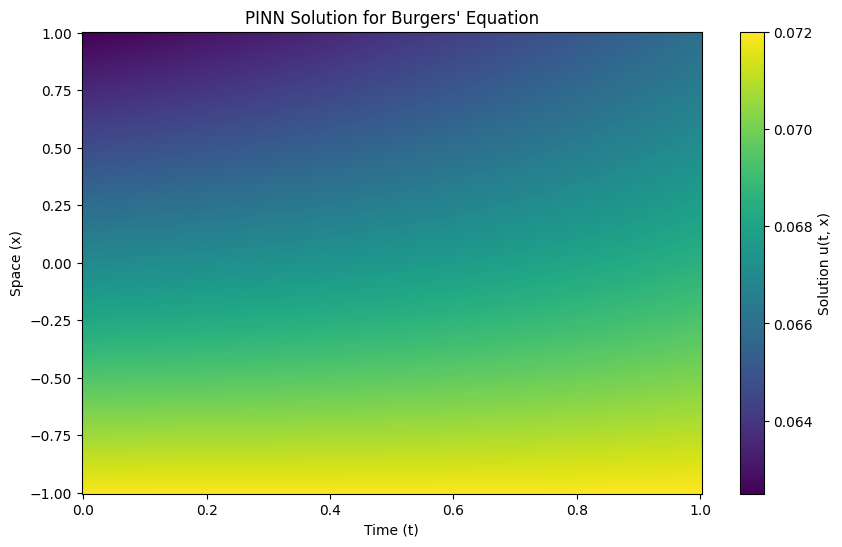

Epoch 10000 | Total: 0.0061150 | ODE: 0.0051925 | IC: 0.0000039 | Eig: 48413.9062500


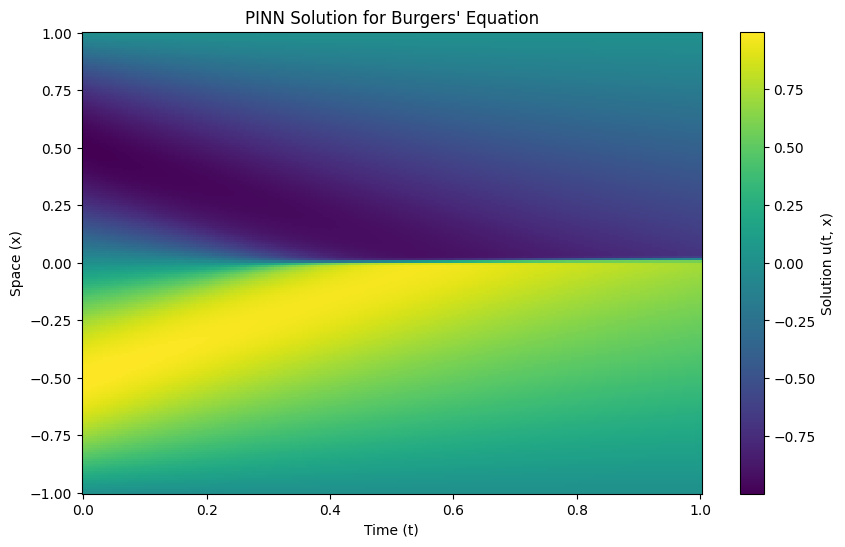

Epoch 20000 | Total: 0.0026488 | ODE: 0.0011191 | IC: 0.0000020 | Eig: 25565.5117188


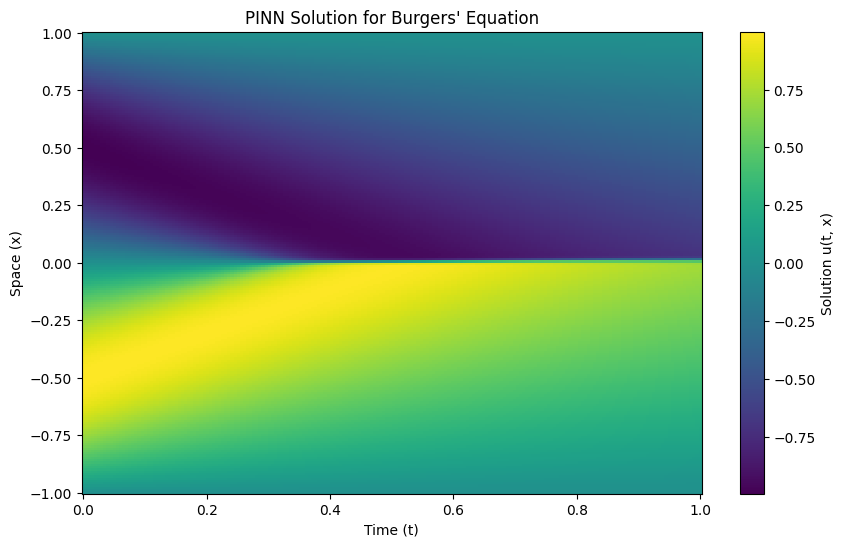

Epoch 30000 | Total: 0.0004616 | ODE: 0.0003586 | IC: 0.0000006 | Eig: 10772.9931641


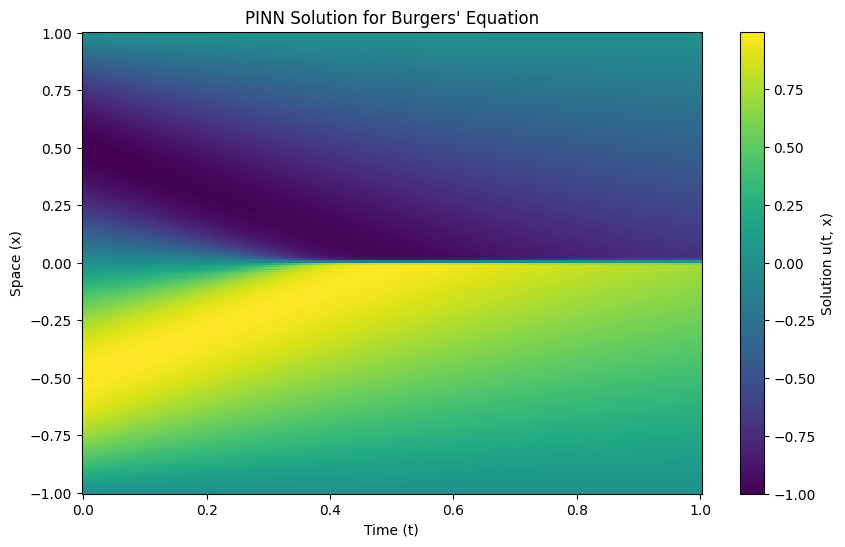

KeyboardInterrupt: 

In [6]:
print("-----------------------------------------")
print(f"Running")
print("-----------------------------------------")

loss_fn = make_loss(nu=0.01 / np.pi) #0.01 / np.pi

model = PINN(64, 4, loss_fn)
scheduler = ExponentialLR(model.optimizer, gamma=0.99)

best_loss = 10

for epoch in range(n_epochs):
    losses = model.train_step(tx_pde)
    #residuals = get_residuals(model, x_co, jac, normalize_jacobian)
    if epoch % 1000 == 0:
        scheduler.step()
    if epoch % 10000 == 0:
        eig_max = model.compute_largest_hessian_eigenvalue(tx_pde)
        print(f"Epoch {epoch:3d} | Total: {losses['total_loss']:.7f} | ODE: {losses['ode_loss']:.7f} | IC: {losses['x0_loss']:.7f} | Eig: {eig_max:.7f}")
        
        #preds = model.predict(tx_pde)
        plotting(model)

    if losses['total_loss'] < best_loss: 
        torch.save(model.state_dict(), 'best-model-parameters.pt')
        best_loss = losses['total_loss']

    if best_loss < early_stopping_loss:
        break

best_model = PINN(64, 4, loss_fn)
best_model.load_state_dict(torch.load("./best-model-parameters.pt"))

preds = best_model.predict(x_co)

plotting(1.0, preds, x_co * 10**4)

eig_max = best_model.compute_largest_hessian_eigenvalue(x_co)

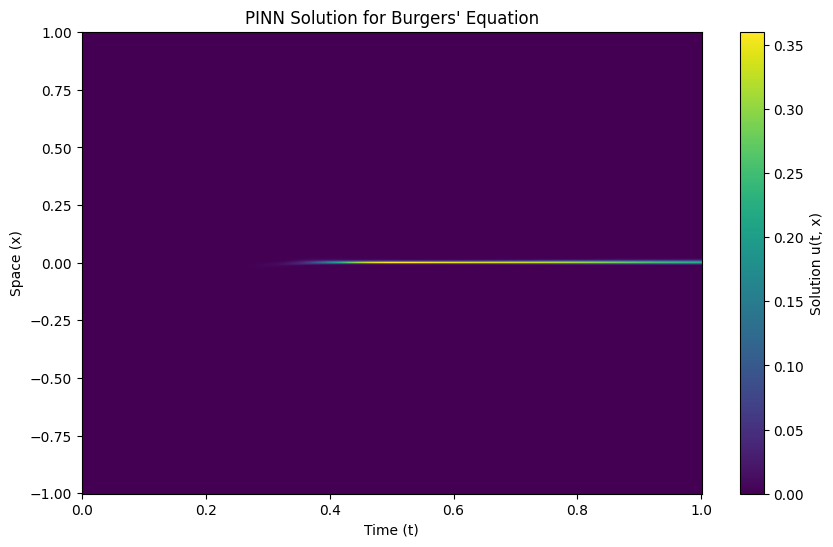

In [23]:
t = torch.linspace(0, 1, 500)  # 200 points in time
x = torch.linspace(-1, 1, 500) # 200 points in space

# Create a meshgrid
T, X = torch.meshgrid(t, x, indexing='ij')

# 2. Prepare the grid for the model
# Flatten the grid to create a batch of (t, x) points
tx_grid = torch.stack((T.flatten(), X.flatten()), dim=1).to('cpu')

# 3. Get predictions from the model on the grid
u_pred = model.predict(tx_grid)

# 4. Reshape the flat predictions back into a 2D grid
U = u_pred.reshape(500, 500).cpu().numpy()

# 5. Create the plot
plt.figure(figsize=(10, 6))

# Use pcolormesh for a heatmap, which is often clearer than contour
plt.pcolormesh(T, X, (u_sol.T- U)**2, shading='auto', cmap='viridis')

# Add a color bar to show the mapping of colors to solution values
plt.colorbar(label='Solution u(t, x)')

plt.xlabel('Time (t)')
plt.ylabel('Space (x)')
plt.title("PINN Solution for Burgers' Equation")
plt.show()

In [ ]:
((u_sol- U)**2).max()

In [ ]:
model.predict()

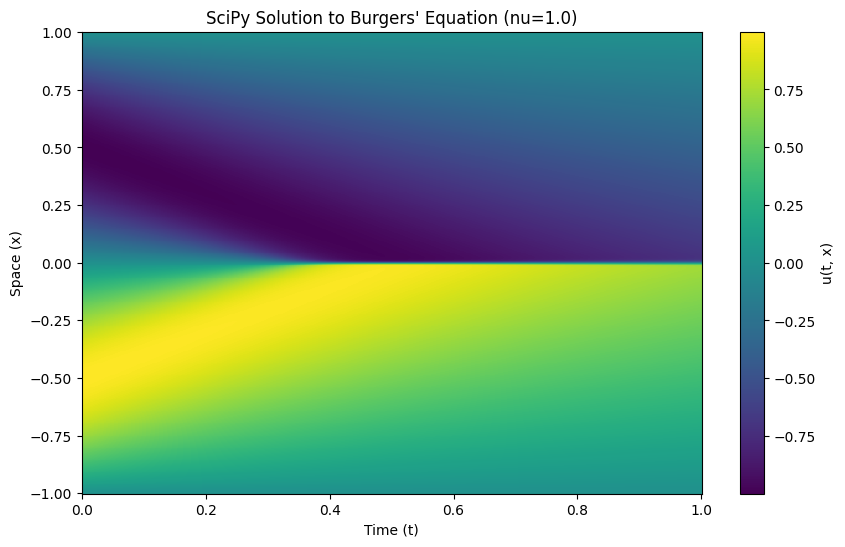

In [22]:
x_grid, t_grid, u_sol = solve_burgers_scipy(nu=0.01/np.pi, Nx=500, Nt=500)

plot_solution_heatmap(x_grid, t_grid, u_sol)


In [17]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def solve_burgers_scipy(nu=0.01/np.pi, Nx=200, Nt=100):
    """
    Solves the 1D Burgers' equation using the Method of Lines with SciPy.
    
    Equation: u_t + u * u_x = nu * u_xx
    Domain: x in [-1, 1], t in [0, 1]
    IC: u(0, x) = -sin(pi*x)
    BC: u(t, -1) = 0, u(t, 1) = 0
    """
    # 1. Define the spatial grid
    x_min, x_max = -1.0, 1.0
    x = np.linspace(x_min, x_max, Nx)
    dx = x[1] - x[0]

    # 2. Define the initial condition
    u0 = -np.sin(np.pi * x)

    # 3. Define the ODE system function for the Method of Lines
    def burgers_ode(t, u, nu, dx, Nx):
        """
        Calculates the time derivative du/dt for the ODE system.
        'u' represents the solution at all spatial points at a given time 't'.
        """
        # Create a temporary array with boundary conditions for easier calculation
        u_full = np.concatenate(([0], u, [0]))

        # Calculate spatial derivatives using central differences
        # First derivative (advection term)
        u_x = (u_full[2:] - u_full[:-2]) / (2 * dx)
        
        # Second derivative (diffusion term)
        u_xx = (u_full[2:] - 2 * u_full[1:-1] + u_full[:-2]) / dx**2
        
        # Calculate the time derivative for the INTERIOR points
        # The boundary points are fixed, so their time derivative is 0
        du_dt = -u * u_x + nu * u_xx
        
        return du_dt


    # 4. Define the time domain and solve the ODE system
    t_min, t_max = 0.0, 1.0
    t_eval = np.linspace(t_min, t_max, Nt)
    
    # We only solve for the interior points, as the boundary points are fixed
    u0_interior = u0[1:-1]

    # Use solve_ivp to integrate the ODE system over time
    solution = solve_ivp(
        burgers_ode,
        t_span=[t_min, t_max],
        y0=u0_interior,
        t_eval=t_eval,
        args=(nu, dx, Nx),
        method='BDF',  
        dense_output=True,      # ensures evaluation at all t_eval
        rtol=1e-6,              # relative tolerance
        atol=1e-8,
    )
    U_dense = solution.sol(t_eval)
    
    # 5. Reconstruct the full solution including boundaries
    u_solution = np.zeros((Nx, Nt))
    u_solution[0, :] = 0  # Boundary at x=-1
    u_solution[-1, :] = 0 # Boundary at x=1
    u_solution[1:-1, :] = U_dense

    return x, t_eval, u_solution

def plot_solution_heatmap(x, t, u):
    """Plots the solution as a 2D heatmap."""
    T, X = np.meshgrid(t, x)
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(T, X, u, shading='auto', cmap='viridis')
    plt.colorbar(label='u(t, x)')
    plt.xlabel('Time (t)')
    plt.ylabel('Space (x)')
    plt.title("SciPy Solution to Burgers' Equation (nu=1.0)")
    plt.show()

## Begin computation

In [ ]:
from sklearn.linear_model import HuberRegressor

# Take logarithms
log_x = np.log(jac_test)
log_y = np.log(lst_eig_max)

# Huber: robust to outliers
huber = HuberRegressor()
huber.fit(log_x.reshape(-1, 1), log_y)

slope = huber.coef_[0]
intercept = huber.intercept_

print(f"Estimated exponent b = {slope:.3f}")
print(f"Estimated coefficient a ≈ exp({intercept:.3f}) = {np.exp(intercept):.3f}")

# Plot
plt.figure(figsize=(10,8))
plt.scatter(log_x, log_y, label="Data (log-log)", marker="+", c='black')
plt.plot(log_x, slope * log_x + intercept, color="red", linestyle='--', label=rf"Fit: $\lambda_{{\max}} \sim \mathcal{{O}} \left( J^{{{slope:.2f}}} \right)$")
plt.xlabel(r"$\log(J)$")
plt.ylabel(r"$\log(\$")
plt.legend()
plt.title("Log–log fit to estimate exponent")
plt.show()

In [ ]:
from sklearn.linear_model import HuberRegressor

# Take logarithms
log_x = np.log(jac_test[:-4])
log_y = np.log(lst_eig_max[:-4])

# Huber: robust to outliers
huber = HuberRegressor()
huber.fit(log_x.reshape(-1, 1), log_y)

slope = huber.coef_[0]
intercept = huber.intercept_

print(f"Estimated exponent b = {slope:.3f}")
print(f"Estimated coefficient a ≈ exp({intercept:.3f}) = {np.exp(intercept):.3f}")

# Plot
plt.figure(figsize=(10,8))
plt.scatter(log_x, log_y, label="Data (log-log)", marker="+", c='black')
plt.plot(log_x, slope * log_x + intercept, color="red", linestyle='--', label=rf"Fit: $\lambda_{{\max}} \sim \mathcal{{O}} \left( J^{{{slope:.2f}}} \right)$")
plt.xlabel(r"$\log(J)$")
plt.ylabel(r"$\log(\$")
plt.legend()
plt.title("Log–log fit to estimate exponent")
plt.show()

In [ ]:
np.log(476)

In [ ]:
break

In [ ]:
dict_eig = dict(zip(jac_test, lst_eig_max))

In [ ]:
import pickle

# Export to a binary pickle file
with open(file_to_save, "wb") as f:
    pickle.dump(dict_eig, f)